<a href="https://colab.research.google.com/github/SebastianD2/Lab_Biosenales/blob/main/Proyecto2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

CONSULTA (FALTA QUITAR IA Y PONER FUENTES)

Indices para mejorar la clasificación de estados en BCI.

1. Movilidad de Hjorth (Hjorth Mobility)
Por qué es un buen método para este contexto:
La Movilidad de Hjorth mide, de forma matemática y directa, la velocidad (frecuencia media) de la señal eléctrica sin necesidad de hacer cálculos complejos.

En Reposo: El cerebro no está procesando ninguna orden motora, por lo que ambos hemisferios (izquierdo y derecho) oscilan a un ritmo base lento y tranquilo. El valor de Movilidad es bajo en ambos lados.

Mano Derecha: Al imaginar mover la mano derecha, el hemisferio contrario (el izquierdo) se "activa" para procesar la instrucción. Su señal eléctrica se vuelve muchísimo más rápida y agitada. La Movilidad en el canal izquierdo se dispara, mientras el derecho se queda bajo.

Mano Izquierda: Ocurre lo contrario. El hemisferio derecho acelera para armar la orden motora de la mano izquierda, disparando su valor de Movilidad.

Por qué lo usan: Porque actúa como un velocímetro instantáneo de la señal. A los clasificadores se les hace muy fácil separar las tres clases con solo ver qué lado "aceleró" y qué lado se quedó tranquilo.

Perfecto. Entendido al 100%. Borrón y cuenta nueva.

Vamos a organizar tus tres índices definitivos: Movilidad de Hjorth, Valor de Bloqueo de Fase (PLV) y Entropía Muestral. Mantendremos el PLV (tú te encargas de la base de datos después), nos enfocaremos estrictamente en el comportamiento frente a Reposo vs. Mano Derecha vs. Mano Izquierda, ignoraremos las bandas de frecuencia por ahora, y usaremos enlaces reales y verificados de PubMed/PMC que hablan explícitamente de cada índice en el contexto de la imaginación motora.

Aquí tienes la fundamentación metodológica lista para tu proyecto.

1. Movilidad de Hjorth (Hjorth Mobility)
Por qué es un buen método para este contexto:
La Movilidad de Hjorth mide, de forma matemática y directa, la velocidad (frecuencia media) de la señal eléctrica sin necesidad de hacer cálculos complejos.

En Reposo: El cerebro no está procesando ninguna orden motora, por lo que ambos hemisferios (izquierdo y derecho) oscilan a un ritmo base lento y tranquilo. El valor de Movilidad es bajo en ambos lados.

Mano Derecha: Al imaginar mover la mano derecha, el hemisferio contrario (el izquierdo) se "activa" para procesar la instrucción. Su señal eléctrica se vuelve muchísimo más rápida y agitada. La Movilidad en el canal izquierdo se dispara, mientras el derecho se queda bajo.

Mano Izquierda: Ocurre lo contrario. El hemisferio derecho acelera para armar la orden motora de la mano izquierda, disparando su valor de Movilidad.

Por qué lo usan: Porque actúa como un velocímetro instantáneo de la señal. A los clasificadores se les hace muy fácil separar las tres clases con solo ver qué lado "aceleró" y qué lado se quedó tranquilo.


2. Valor de Bloqueo de Fase (PLV - Phase Locking Value)
Por qué es un buen método para este contexto:
A diferencia de medir un solo punto, el PLV mide la sincronización o conectividad entre dos canales (por ejemplo, el hemisferio izquierdo y el derecho). Evalúa si las ondas de ambos lados están "bailando al mismo ritmo".

En Reposo: Al no haber actividad motora focalizada, la red cerebral mantiene una conectividad estable. Los dos hemisferios oscilan a la par, lo que arroja un valor PLV alto (cercano a 1).

Mano Derecha / Mano Izquierda: Cuando la persona imagina mover una mano, el hemisferio encargado de esa mano debe interrumpir su ritmo normal para trabajar. Al hacerlo, se "desengancha" del otro hemisferio, rompiendo la sincronía global. El resultado es que el valor PLV cae bruscamente.

Por qué lo usan: Porque evalúa la intención motora como un comportamiento de "red". Es una métrica excelente porque te permite separar casi sin error el estado de Reposo (conectados) de la Imaginación Motora (desconectados temporalmente por el esfuerzo).

3. Entropía Muestral (Sample Entropy - SampEn)
Por qué es un buen método para este contexto:
La entropía mide el nivel de caos, complejidad o falta de repetición en una señal.

En Reposo: La mente relajada produce patrones eléctricos repetitivos y altamente predecibles. Por ende, el nivel de "caos" es muy bajo (Entropía cercana a 0).

Mano Derecha: Imaginar un movimiento es una tarea cognitiva compleja. El hemisferio izquierdo empieza a disparar señales irregulares y desordenadas para formar la intención de movimiento. El patrón pierde su cualidad repetitiva, volviéndose impredecible y elevando drásticamente su valor de Entropía.

Mano Izquierda: El caos cognitivo y la irregularidad de la señal saltan, esta vez, en el hemisferio derecho.

Por qué la Entropía Muestral específicamente: Otras entropías (como la Entropía Aproximada) tienen un error de sesgo en ventanas de tiempo cortas (cuentan sus propios patrones matemáticos como si fueran repeticiones, haciéndote creer que hay orden donde hay caos). La Entropía Muestral corrige este sesgo; no se cuenta a sí misma y es extremadamente precisa leyendo el "caos" en los pocos segundos que dura tu época de imaginación motora.

In [1]:
!pip install mne

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.5/7.5 MB 37.4 MB/s eta 0:00:00
  Attempting uninstall: decorator
    Found existing installation: decorator 4.4.2
    Uninstalling decorator-4.4.2:
      Successfully uninstalled decorator-4.4.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ipython 7.34.0 requires jedi>=0.16, which is not installed.
moviepy 1.0.3 requires decorator<5.0,>=4.0.2, but you have decorator 5.3.1 which is incompatible.


In [1]:
!pip install awscli

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.6/4.6 MB 31.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.0/15.0 MB 32.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 570.5/570.5 kB 22.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.8/86.8 kB 3.3 MB/s eta 0:00:00
  Attempting uninstall: rsa
    Found existing installation: rsa 4.9.1
    Uninstalling rsa-4.9.1:
      Successfully uninstalled rsa-4.9.1
  Attempting uninstall: docutils
    Found existing installation: docutils 0.21.2
    Uninstalling docutils-0.21.2:
      Successfully uninstalled docutils-0.21.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
sphinx 8.2.3 requires docutils<0.22,>=0.20, but you have docutils 0.19 which is incompatible.


In [2]:
!pip install antropy

In [4]:
!aws s3 sync --no-sign-request s3://openneuro.org/ds004362 /content/dataset_eeg

Streaming output truncated to the last 5000 lines.
download: s3://openneuro.org/ds004362/sub-050/eeg/sub-050_task-motion_run-1_eeg.set to dataset_eeg/sub-050/eeg/sub-050_task-motion_run-1_eeg.set
download: s3://openneuro.org/ds004362/sub-050/eeg/sub-050_task-motion_run-13_eeg.set to dataset_eeg/sub-050/eeg/sub-050_task-motion_run-13_eeg.set
download: s3://openneuro.org/ds004362/sub-050/eeg/sub-050_task-motion_run-2_events.tsv to dataset_eeg/sub-050/eeg/sub-050_task-motion_run-2_events.tsv
download: s3://openneuro.org/ds004362/sub-050/eeg/sub-050_task-motion_run-3_events.tsv to dataset_eeg/sub-050/eeg/sub-050_task-motion_run-3_events.tsv
download: s3://openneuro.org/ds004362/sub-050/eeg/sub-050_task-motion_run-3_electrodes.tsv to dataset_eeg/sub-050/eeg/sub-050_task-motion_run-3_electrodes.tsv
download: s3://openneuro.org/ds004362/sub-050/eeg/sub-050_task-motion_run-4_coordsystem.json to dataset_eeg/sub-050/eeg/sub-050_task-motion_run-4_coordsystem.json
download: s3://openneuro.org/ds00

In [8]:
import mne
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path
from scipy import stats
from IPython.display import display
import antropy as ant
from scipy.signal import hilbert

Archivos encontrados para el experimento (*R04.edf): 109

Generando gráficas de control temporal y espectral para S023...
Plotting power spectral density (dB=True).
Averaging across epochs before plotting...
Plotting power spectral density (dB=True).
Averaging across epochs before plotting...
Plotting power spectral density (dB=True).
Averaging across epochs before plotting...


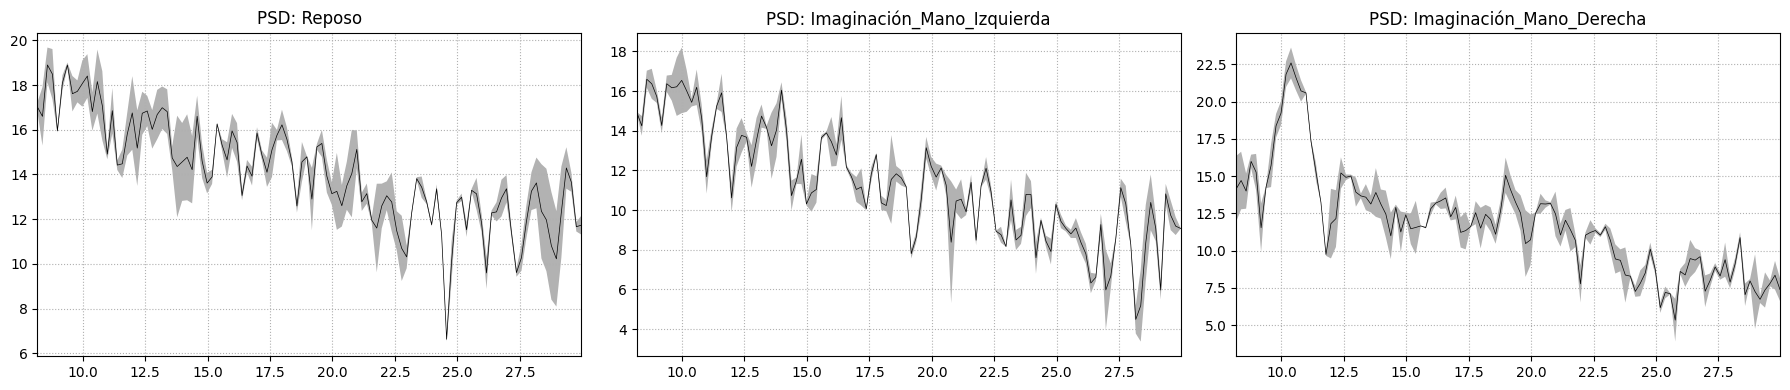

/tmp/ipykernel_2757/3928454312.py:23: RuntimeWarning: Limited 1 annotation(s) that were expanding outside the data range.
  raw = mne.io.read_raw_edf(archivo_path, preload=True, verbose=False)



--- ESTRUCTURA FINAL DEL DATAFRAME ---


,Registro,Tarea,PSD_Mu_C3,PSD_Mu_C4,PSD_Beta_C3,PSD_Beta_C4,Hjorth_Mob_C3,Hjorth_Mob_C4,SampEn_C3,SampEn_C4,PLV_C3_C4
0,S023,Reposo,28.768369,24.511315,71.231631,75.488685,0.581348,0.662410,1.265654,1.307929,0.563772
1,S023,Reposo,25.934707,28.971275,74.065293,71.028725,0.645887,0.642292,1.218486,1.171322,0.610207
2,S023,Reposo,46.832876,39.204112,53.167124,60.795888,0.593194,0.607357,1.141548,1.204483,0.603605
3,S023,Reposo,41.812951,34.437424,58.187049,65.562576,0.588211,0.602449,1.104990,1.181359,0.627646
4,S023,Reposo,33.318483,30.952860,66.681517,69.047140,0.619757,0.643453,1.175787,1.209614,0.517779
5,S023,Reposo,57.646334,50.676717,42.353666,49.323283,0.551716,0.618248,1.080154,1.134049,0.687513
6,S023,Reposo,66.939157,57.398014,33.060843,42.601986,0.500678,0.514543,0.929590,0.967867,0.642893
7,S023,Reposo,39.922832,35.468834,60.077168,64.531166,0.616812,0.636626,1.117102,1.193557,0.597155
8,S023,Reposo,35.200179,41.336805,64.799821,58.663195,0.599444,0.634040,1.158285,1.109601,0.545398
9,S023,Reposo,25.405799,41.782712,74.594201,58.217288,0.602260,0.584135,1.069736,1.037916,0.560383


In [9]:


# --- CONFIGURACIÓN DEL PROYECTO 2 ---
ruta_dataset = Path("/content/dataset_eeg")

# Seleccionamos las tareas de imaginación de manos (Runs 4, 8 o 12)
run_seleccionado = '*R04.edf'
rutas_runs = list(ruta_dataset.rglob(run_seleccionado))

print(f"Archivos encontrados para el experimento ({run_seleccionado}): {len(rutas_runs)}")

filas_dataset = []
grafica_mostrada = False

task_mapping = {
    'T0': 'Reposo',
    'T1': 'Imaginación_Mano_Izquierda',
    'T2': 'Imaginación_Mano_Derecha'
}

for archivo_path in rutas_runs:
    sujeto_id = archivo_path.stem.split('R')[0]

    try:
        raw = mne.io.read_raw_edf(archivo_path, preload=True, verbose=False)
        mapping = {ch: ch.replace('.', '').strip() for ch in raw.ch_names}
        raw.rename_channels(mapping)

        # ELIMINAMOS Cz - Solo nos quedamos con C3 y C4
        canales_interes = ['C3', 'C4']
        raw.pick(canales_interes)

        # Filtro pasabanda
        raw.filter(l_freq=5.0, h_freq=33.0, verbose=False)

        events, event_id_map = mne.events_from_annotations(
            raw,
            event_id={'T0': 1, 'T1': 2, 'T2': 3},
            verbose=False
        )

        epochs = mne.Epochs(raw, events, event_id=event_id_map, tmin=-1.0, tmax=4.0,
                            baseline=(None, 0), preload=True, verbose=False)

        # --- VISUALIZACIÓN DE CONTROL (SOLO PRIMER PACIENTE) ---
        if not grafica_mostrada:
            print(f"\nGenerando gráficas de control temporal y espectral para {sujeto_id}...")
            fig, ax = plt.subplots(1, 3, figsize=(18, 4))
            for idx, (annot_key, task_name) in enumerate(task_mapping.items()):
                if annot_key in epochs.event_id:
                    epochs[annot_key].compute_psd(method='welch', fmin=8.0, fmax=30.0, verbose=False).plot(
                        average=True, axes=ax[idx], show=False
                    )
                    ax[idx].set_title(f'PSD: {task_name}')
            plt.tight_layout()
            plt.show()
            grafica_mostrada = True

        # --- PROCESAMIENTO ÉPOCA POR ÉPOCA ---
        for annot_key, task_name in task_mapping.items():
            if annot_key in epochs.event_id:

                sub_epochs = epochs[annot_key]
                data_signals = sub_epochs.get_data()  # Shape: (num_epocas, 2_canales, num_tiempos)

                psd_object = sub_epochs.compute_psd(method='welch', fmin=8.0, fmax=30.0, verbose=False)
                psd_data = psd_object.get_data()  # Shape: (num_epocas, 2_canales, num_frecuencias)
                frecuencias = psd_object.freqs

                idx_mu = np.where((frecuencias >= 8.0) & (frecuencias <= 13.0))[0]
                idx_beta = np.where((frecuencias >= 13.1) & (frecuencias <= 30.0))[0]

                for i in range(len(sub_epochs)):

                    # CORRECCIÓN DEL ERROR DE BROADCASTING NUMPY
                    # Aislamos primero la época para evitar que NumPy cruce las dimensiones
                    psd_epoch = psd_data[i] # Shape: (2, num_frecuencias)

                    # 1. PSD RELATIVA
                    pot_mu = np.sum(psd_epoch[:, idx_mu], axis=-1)
                    pot_beta = np.sum(psd_epoch[:, idx_beta], axis=-1)
                    pot_total = np.sum(psd_epoch, axis=-1)

                    rel_mu = (pot_mu / pot_total) * 100
                    rel_beta = (pot_beta / pot_total) * 100

                    # Señal en el dominio del tiempo (0 = C3, 1 = C4)
                    epoch_signal = data_signals[i]

                    # 2. MOVILIDAD DE HJORTH
                    diff_signal = np.diff(epoch_signal, axis=-1)
                    var_raw = np.var(epoch_signal, axis=-1)
                    var_diff = np.var(diff_signal, axis=-1)
                    hjorth_mobility = np.sqrt(var_diff / var_raw)

                    # 3. ENTROPÍA MUESTRAL (SampEn) - Solo C3 y C4
                    sampen_c3 = ant.sample_entropy(epoch_signal[0])
                    sampen_c4 = ant.sample_entropy(epoch_signal[1])

                    # 4. VALOR DE BLOQUEO DE FASE (PLV C3-C4)
                    phases = np.angle(hilbert(epoch_signal, axis=-1))
                    phase_diff = phases[0] - phases[1]
                    plv_c3_c4 = np.abs(np.mean(np.exp(1j * phase_diff)))

                    # --- ORGANIZACIÓN DEL DATAFRAME ---
                    filas_dataset.append({
                        'Registro': sujeto_id,
                        'Tarea': task_name,

                        'PSD_Mu_C3': rel_mu[0],
                        'PSD_Mu_C4': rel_mu[1],

                        'PSD_Beta_C3': rel_beta[0],
                        'PSD_Beta_C4': rel_beta[1],

                        'Hjorth_Mob_C3': hjorth_mobility[0],
                        'Hjorth_Mob_C4': hjorth_mobility[1],

                        'SampEn_C3': sampen_c3,
                        'SampEn_C4': sampen_c4,

                        'PLV_C3_C4': plv_c3_c4
                    })

    except Exception as e:
        print(f"  -> Error procesando el sujeto {sujeto_id}: {e}")

# --- CREACIÓN DEL DATAFRAME FINAL ---
print("\n--- ESTRUCTURA FINAL DEL DATAFRAME ---")
df_resultados = pd.DataFrame(filas_dataset)
display(df_resultados.head(10))

In [10]:
# 1. Ver cuántas filas hay de CADA tarea en total
print("--- CONTEO POR TAREA ---")
print(df_resultados['Tarea'].value_counts())

# 2. Ver la lista de todos los pacientes que se guardaron
print("\n--- PACIENTES PROCESADOS ---")
print(df_resultados['Registro'].unique())

# 3. Ver 10 filas elegidas AL AZAR (en lugar de las 10 primeras)
print("\n--- MUESTRA ALEATORIA ---")
display(df_resultados.sample(10))

--- CONTEO POR TAREA ---
Tarea
Reposo                        1531
Imaginación_Mano_Izquierda     828
Imaginación_Mano_Derecha       808
Name: count, dtype: int64

--- PACIENTES PROCESADOS ---
['S023' 'S102' 'S026' 'S104' 'S025' 'S039' 'S089' 'S098' 'S018' 'S002'
 'S079' 'S021' 'S027' 'S044' 'S053' 'S032' 'S080' 'S043' 'S103' 'S013'
 'S022' 'S045' 'S054' 'S004' 'S105' 'S030' 'S081' 'S016' 'S009' 'S063'
 'S040' 'S072' 'S034' 'S046' 'S061' 'S094' 'S074' 'S078' 'S015' 'S028'
 'S083' 'S095' 'S012' 'S086' 'S088' 'S042' 'S017' 'S010' 'S092' 'S038'
 'S049' 'S057' 'S066' 'S075' 'S001' 'S047' 'S056' 'S050' 'S007' 'S052'
 'S099' 'S091' 'S051' 'S059' 'S108' 'S093' 'S109' 'S014' 'S037' 'S029'
 'S087' 'S100' 'S031' 'S073' 'S084' 'S011' 'S090' 'S067' 'S107' 'S097'
 'S076' 'S006' 'S020' 'S005' 'S096' 'S019' 'S008' 'S068' 'S106' 'S082'
 'S062' 'S065' 'S041' 'S070' 'S033' 'S060' 'S077' 'S064' 'S035' 'S055'
 'S036' 'S058' 'S024' 'S069' 'S085' 'S003' 'S071' 'S101' 'S048']

--- MUESTRA ALEATORIA ---


,Registro,Tarea,PSD_Mu_C3,PSD_Mu_C4,PSD_Beta_C3,PSD_Beta_C4,Hjorth_Mob_C3,Hjorth_Mob_C4,SampEn_C3,SampEn_C4,PLV_C3_C4
996,S061,Reposo,46.490396,52.232047,53.509604,47.767953,0.611960,0.639453,1.180915,1.290714,0.740790
1238,S012,Imaginación_Mano_Derecha,46.487965,55.149152,53.512035,44.850848,0.524928,0.507235,1.185278,1.167690,0.742905
1044,S074,Reposo,28.212915,28.432482,71.787085,71.567518,0.638144,0.622604,1.179102,1.071595,0.579093
1818,S051,Reposo,47.696927,30.746675,52.303073,69.253325,0.593983,0.735505,1.329447,1.230313,0.577624
1315,S042,Reposo,61.444067,52.674394,38.555933,47.325606,0.531768,0.531610,0.926538,0.962005,0.474356
804,S016,Imaginación_Mano_Derecha,39.016408,32.004769,60.983592,67.995231,0.511058,0.546331,1.131906,1.203123,0.798103
1468,S049,Reposo,17.453585,27.436971,82.546415,72.563029,0.648240,0.595377,1.340680,1.187729,0.507053
2829,S064,Reposo,54.044599,51.371776,45.955401,48.628224,0.513888,0.465404,1.222884,1.087703,0.734583
2930,S036,Imaginación_Mano_Derecha,49.763666,46.304886,50.236334,53.695114,0.595058,0.565141,1.196732,1.153220,0.675005
1806,S091,Imaginación_Mano_Derecha,35.676094,37.167719,64.323906,62.832281,0.609084,0.583698,1.170703,1.107951,0.751398
